In [2]:
%load_ext autoreload
%autoreload 2

import actionet
import scipy
import numpy as np
import scanpy as sc
import anndata
import pandas as pd

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
adata = anndata.read_h5ad("../data/test_adata_post.h5ad")

In [4]:
markers = actionet.find_markers(adata, adata.obs['CellLabel'], features_use="Gene", top_genes=30, return_type='dataframe')

Computing feature specificity ... done


In [5]:
markers

,CT_1,CT_10,CT_11,CT_12,CT_13,CT_14,CT_15,CT_16,CT_2,CT_3,CT_4,CT_5,CT_6,CT_7,CT_8,CT_9
0,Slc1a2,Adarb2,Plp1,Xylt1,Sox2ot,Lingo2,Penk,Mrc1,Bsg,Adamts20,Slc38a2,Cpne4,Grip1,Sox2ot,Plxdc2,Dlc1
1,Msi2,Pcdh15,Mbp,Lhfpl3,Adarb2,Ebf1,Drd2,Slc9a9,Igf1r,Cfap299,Cemip,Clstn2,Erbb4,Sox6,Hexb,Atp13a5
2,Gpc5,Olfm3,Plcl1,Tnr,2610307P16Rik,Sntg2,Grik3,Stab1,Tmsb4x,Spag16,Ptgds,Asic2,Il1rapl2,Col25a1,Tmcc3,Cald1
3,Apoe,Erbb4,Edil3,Dscam,Pbx1,Nrg3,Adora2a,P2rx7,mt-Co1,Cfap54,Fbxl7,Inpp4b,Astn2,Nos1,Tgfbr1,Pdgfrb
4,Slc1a3,Trpm3,Fnbp1,Ptprz1,Sdk2,Reln,Chrm3,Rbpj,Sgms1,Ccdc162,Slc4a10,Kcnt2,Tcf4,Ptprt,Inpp5d,Colec12
5,Plpp3,Ntng1,Tmeff2,Epn2,Nfib,Cntnap3,Nell1,Dab2,Ptprg,Spef2,Cped1,Prkca,Pcdh15,Aff2,Lrmda,Dock6
6,Prex2,Foxp2,Mast4,Vcan,Sox1ot,Onecut2,Sgcz,Gab2,mt-Co2,Cfap61,Eya2,Ptchd4,Dlgap1,Zfp804b,Cx3cr1,Phldb2
7,Nfia,Tshz1,Rnf220,Arhgap31,Ppm1e,Samd5,Necab1,Anapc15,Spock2,Kif6,Slc7a11,Galntl6,Nxph1,Tox,Apbb1ip,Atp1a2
8,Mir99ahg,Alk,St6galnac3,Tmem132d,Dlx6os1,Dgkz,Cacnb2,Ctsc,mt-Co3,Cfap46,Trpm3,Slc7a14,Ppm1l,Sst,Lyn,Plxdc2
9,Cpe,Sgcd,Pex5l,Maml2,Tcf4,Ccdc88c,Ptprm,Tnfrsf11a,Gpcpd1,Ak7,Sned1,Fam155a,Srrm4,Tenm1,Rreb1,Vtn


In [15]:
annots_out = actionet.annotate_cells(adata, markers, layer = 'logcounts', method='vision', features_use='Gene', network_key='actionet', use_enrichment=True, use_lpa=False, n_threads=0)

In [16]:
adata.obs['annot'] = annots_out['labels']
adata.obs['annot_conf'] = annots_out['confidence']
adata.obsm['annot_enrichment'] = annots_out['enrichment']

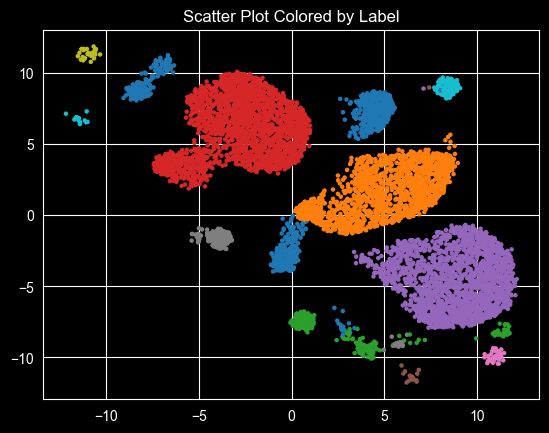

In [17]:
labels = pd.Series(annots_out['labels']).astype('category')
colors = labels.cat.codes  # Convert categories to integers

plt.scatter(
    x=adata.obsm['umap'][:, 0],
    y=adata.obsm['umap'][:, 1],
    c=colors,
    cmap='tab10',  # or another categorical colormap
    alpha=np.clip(annots_out['confidence'], 0, 1.0),
    s = 5
)
# plt.xlabel('X')
# plt.ylabel('Y')
plt.title('Scatter Plot Colored by Label')
# plt.colorbar(label='CellLabel')
plt.show()

In [25]:
adata.obsm['annot_enrichment']

array([[ 0.84692221,  5.16957668,  2.01301117, ...,  0.94684403,
        -0.62910251,  0.27810869],
       [ 0.54361674,  4.38639992,  1.33457536, ...,  0.70440643,
        -0.73441925,  0.20820462],
       [ 0.83209428,  5.46601227,  2.48789602, ...,  1.66506246,
        -0.68291121,  0.40855551],
       ...,
       [ 0.45073863,  3.14923505,  1.18233359, ...,  0.79670387,
        -0.48084829,  0.06167929],
       [ 3.30512377,  2.44421903, 27.74789117, ...,  1.1455623 ,
         1.13382587,  1.3821365 ],
       [ 3.36968475,  2.54875422, 29.16656976, ...,  1.32589484,
         0.74016857,  1.18187583]], shape=(6790, 16))

In [26]:
# adata.write_h5ad("../data/test_adata_post_annot.h5ad")

In [27]:
markers.to_csv("../data/test_markers.csv", sep=',', header=True, index=False)